In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers,models,optimizers,callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import cv2
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
DataSet_Directory=r'C:\Users\abdul\OneDrive\Desktop\Semester 7\CV\Project\Food Quality Inspection Model\Food Quality Inspection DataSet\FRUIT-16K'
HSI_Directory=r'C:\Users\abdul\OneDrive\Desktop\Semester 7\CV\Project\Food Quality Inspection Model\Food Quality Inspection DataSet\HSI_Data'
#Image_Size=(224,224)
#Batch_Size=32
#Seed=4
#Initial_Epochs=15
#Fine_Tune_Epochs=10
#Total_Epochs=Initial_Epochs+Fine_Tune_Epochs

#Pseudo_Spectral_Channel=5
#Learning_Rate=1e-4
#Learning_Rate_FineTune=1e-5
#Model_Save="Food_Quality_Inspection_Model.h5"

#DataSet_Directory=r'/content/drive/MyDrive/Food Quality Inspection DataSet/FRUIT-16K'
#HSI_Directory=r'/content/drive/MyDrive/HSI_Data'
Image_Size=(224,224)
Batch_Size=32
Seed=4
Initial_Epochs=20
Fine_Tune_Epochs=10
Total_Epochs=Initial_Epochs+Fine_Tune_Epochs

Pseudo_Spectral_Channel=5
True_HSI_Band=31
Use_True_HSI=False
Learning_Rate=1e-4
Learning_Rate_FineTune=1e-5
Model_Save="Food_Quality_Inspection_Model.h5"

In [5]:
Training_DataGen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.7,1.3),
    shear_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='reflect'
)

Training_Gen=Training_DataGen.flow_from_directory(
    DataSet_Directory,
    target_size=Image_Size,
    batch_size=Batch_Size,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=Seed
)

Validation_Gen=Training_DataGen.flow_from_directory(
    DataSet_Directory,
    target_size=Image_Size,
    batch_size=Batch_Size,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=Seed
)

Found 14251 images belonging to 2 classes.
Found 3562 images belonging to 2 classes.


In [6]:
Classes=Training_Gen.classes
Class_Name=list(Training_Gen.class_indices.keys())
print(f"Class Indices : {Training_Gen.class_indices}")

Class_Weights=compute_class_weight('balanced',classes=np.unique(Classes),y=Classes)
Class_Weights={i:w for i,w in enumerate(Class_Weights)}
print(f"Computed Class Weights : {Class_Weights}")

Class Indices : {'Fresh': 0, 'Spoiled': 1}
Computed Class Weights : {0: 0.9896527777777778, 1: 1.0105658771805417}


In [7]:
def Simulate_HSI_From_RGB(RGB_Image,Num_Bands=31):
  Height,Width=RGB_Image.shape[:2]
  HSI_Cube=np.zeros((Height,Width,Num_Bands),dtype=np.float32)

  RGB_Wavelengths=np.array([630,530,450])
  Target_Wavelengths=np.linspace(400,700,Num_Bands)

  for i,Target_WL in enumerate(Target_Wavelengths):
    Weights=np.exp(-((RGB_Wavelengths-Target_WL)**2)/(2*50**2))
    Weights=Weights/Weights.sum()
    HSI_Cube[:,:,i]=np.sum(RGB_Image*Weights,axis=2)
  
  return HSI_Cube

In [8]:
def Extract_Spectral_Indices(HSI_Cube):
  if HSI_Cube.shape[2]>=10:
    Red_Band=HSI_Cube[:,:,15]
    NIR_Band=HSI_Cube[:,:,25]

    NDVI=(NIR_Band-Red_Band)/(NIR_Band+Red_Band+1e-8)

    return np.expand_dims(NDVI,axis=-1)
  else:
    return HSI_Cube[:,:,5]


In [9]:
class HSI_RGB_Generator(tf.keras.utils.Sequence):
  def __init__(self,RGB_Generator,Use_True_HSI=False,HSI_Dir=None):
    self.RGB_Generator=RGB_Generator
    self.Use_True_HSI=Use_True_HSI
    self.HSI_Dir=HSI_Dir
  
  def __Len__(self):
    return len(self.RGB_Generator)
  
  def __GetItem__(self,Index):
    RGB_Batch,Labels=self.RGB_Generator[Index]
    HSI_Batch=np.array([Simulate_HSI_From_RGB(Image,True_HSI_Band) for Image in RGB_Batch])

    return {'RGB_Input' : RGB_Batch, 'HSI_Input' : HSI_Batch},Labels


In [10]:
def Build_Hybrid_HSI_Model(Img_Size=Image_Size,Pseudo_Channels=Pseudo_Spectral_Channel,HSI_Bands=True_HSI_Band,Use_True_HSI=Use_True_HSI):
    RGB_Input = layers.Input(shape=(Img_Size[0],Img_Size[1], 3), name='RGB_Input')
    Base_Model = tf.keras.applications.MobileNetV2(
        input_shape=(Img_Size[0],Img_Size[1], 3),
        include_top=False,
        weights='imagenet'
    )
    Base_Model.trainable = False
    
    x = Base_Model(RGB_Input)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    RGB_Feat = layers.Dense(128, activation='relu', name='rgb_features')(x)
    
    Y = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(RGB_Input)
    Y = layers.BatchNormalization()(Y)
    Y = layers.MaxPooling2D((2, 2))(Y)
    Y = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(Y)
    Y = layers.BatchNormalization()(Y)
    Y = layers.MaxPooling2D((2, 2))(Y)
    
    Pseudo = layers.Conv2D(Pseudo_Channels, (1, 1), activation='linear',name='Pseudo_Spectral_Maps')(Y)
    
    Z = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(Pseudo)
    Z = layers.GlobalAveragePooling2D()(Z)
    Z = layers.BatchNormalization()(Z)
    Pseudo_Feat = layers.Dense(64, activation='relu', name='pseudo_features')(Z)
    
    if Use_True_HSI:
        HSI_Input = layers.Input(shape=(Img_Size[0],Img_Size[1],HSI_Bands), name='HSI_Input')
        
        H = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(HSI_Input)
        H = layers.BatchNormalization()(H)
        H = layers.MaxPooling2D((2, 2))(H)
        
        H = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(H)
        H = layers.BatchNormalization()(H)
        H = layers.MaxPooling2D((2, 2))(H)
        
        H = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(H)
        H = layers.GlobalAveragePooling2D()(H)
        H = layers.BatchNormalization()(H)
        H = layers.Dense(128, activation='relu')(H)
        H = layers.Dropout(0.3)(H)
        HSI_Feat = layers.Dense(64, activation='relu', name='HSI_Features')(H)
        
        Fused = layers.Concatenate(name='fusion')([RGB_Feat, Pseudo_Feat, HSI_Feat])
        Inputs = [RGB_Input, HSI_Input]
    else:
        Fused = layers.Concatenate(name='Fusion')([RGB_Feat,Pseudo_Feat])
        Inputs = RGB_Input
    
    Fused = layers.BatchNormalization()(Fused)
    Fused = layers.Dense(128, activation='relu')(Fused)
    Fused = layers.Dropout(0.5)(Fused)
    Fused = layers.Dense(64, activation='relu')(Fused)
    Output = layers.Dense(1, activation='sigmoid', name='output')(Fused)
    
    model = models.Model(inputs=Inputs, outputs=Output, 
                        name='Hybrid_RGB_Pseudospec_HSI_Model')
    
    return model, Base_Model


In [11]:
Model,BackBone=Build_Hybrid_HSI_Model(Use_True_HSI=Use_True_HSI)
Model.summary()

Model: "Hybrid_RGB_Pseudospec_HSI_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ RGB_Input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ RGB_Input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ RGB_Input[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pseudo_Spectral_Ma… │ (None, 56, 56, 5) │        325 │ max_pooling2d_1[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │      2,944 │ Pseudo_Spectral_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_features        │ (None, 128)       │     32,896 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,685,190 (10.24 MB)

 Trainable params: 423,942 (1.62 MB)

 Non-trainable params: 2,261,248 (8.63 MB)

In [12]:
Model.compile(
    optimizer=optimizers.Adam(learning_rate=Learning_Rate),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]

)

CheckPoint_CB = callbacks.ModelCheckpoint('best_hybrid_hsi_model.h5',monitor='val_auc',mode='max',save_best_only=True)
History1=Model.fit(
    Training_Gen,
    epochs=Initial_Epochs,
    validation_data=Validation_Gen,
    class_weight=Class_Weights,
    callbacks=[CheckPoint_CB]
)

c:\Users\abdul\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7067 - auc: 0.7724 - loss: 0.5686

446/446 ━━━━━━━━━━━━━━━━━━━━ 654s 1s/step - accuracy: 0.7069 - auc: 0.7726 - loss: 0.5683 - val_accuracy: 0.6277 - val_auc: 0.7247 - val_loss: 0.8466
Epoch 2/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.9298 - auc: 0.9792 - loss: 0.1892

446/446 ━━━━━━━━━━━━━━━━━━━━ 536s 1s/step - accuracy: 0.9298 - auc: 0.9792 - loss: 0.1892 - val_accuracy: 0.6098 - val_auc: 0.7602 - val_loss: 1.1526
Epoch 3/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 531s 1s/step - accuracy: 0.9501 - auc: 0.9891 - loss: 0.1299 - val_accuracy: 0.5809 - val_auc: 0.7532 - val_loss: 1.6404
Epoch 4/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 561s 1s/step - accuracy: 0.9639 - auc: 0.9942 - loss: 0.0948 - val_accuracy: 0.5924 - val_auc: 0.7498 - val_loss: 1.6078
Epoch 5/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 545s 1s/step - accuracy: 0.9736 - auc: 0.9967 - loss: 0.0712 - val_accuracy: 0.5912 - val_auc: 0.7340 - val_loss: 1.9458
Epoch 6/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 575s 1s/step - accuracy: 0.9749 - auc: 0.9967 - loss: 0.0684 - val_accuracy: 0.5845 - val_auc: 0.7495 - val_loss: 1.6428
Epoch 7/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9767 - auc: 0.9970 - loss: 0.0630

446/446 ━━━━━━━━━━━━━━━━━━━━ 649s 1s/step - accuracy: 0.9767 - auc: 0.9970 - loss: 0.0630 - val_accuracy: 0.5938 - val_auc: 0.7671 - val_loss: 1.7110
Epoch 8/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 700s 2s/step - accuracy: 0.9800 - auc: 0.9971 - loss: 0.0576 - val_accuracy: 0.5809 - val_auc: 0.7384 - val_loss: 2.1773
Epoch 9/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 765s 2s/step - accuracy: 0.9826 - auc: 0.9982 - loss: 0.0477 - val_accuracy: 0.6070 - val_auc: 0.7606 - val_loss: 1.7535
Epoch 10/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 819s 2s/step - accuracy: 0.9843 - auc: 0.9987 - loss: 0.0429 - val_accuracy: 0.5873 - val_auc: 0.7157 - val_loss: 1.9780
Epoch 11/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 546s 1s/step - accuracy: 0.9848 - auc: 0.9986 - loss: 0.0412 - val_accuracy: 0.6070 - val_auc: 0.7439 - val_loss: 1.7137
Epoch 12/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.9851 - auc: 0.9988 - loss: 0.0379 - val_accuracy: 0.6176 - val_auc: 0.7574 - val_loss: 1.6718
Epoch 13/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 6

446/446 ━━━━━━━━━━━━━━━━━━━━ 743s 2s/step - accuracy: 0.9878 - auc: 0.9990 - loss: 0.0339 - val_accuracy: 0.6179 - val_auc: 0.7768 - val_loss: 1.6638
Epoch 16/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 666s 1s/step - accuracy: 0.9871 - auc: 0.9991 - loss: 0.0334 - val_accuracy: 0.5938 - val_auc: 0.7553 - val_loss: 1.9210
Epoch 17/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9899 - auc: 0.9992 - loss: 0.0311

446/446 ━━━━━━━━━━━━━━━━━━━━ 657s 1s/step - accuracy: 0.9899 - auc: 0.9992 - loss: 0.0311 - val_accuracy: 0.6668 - val_auc: 0.7908 - val_loss: 1.3040
Epoch 18/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 596s 1s/step - accuracy: 0.9883 - auc: 0.9988 - loss: 0.0352 - val_accuracy: 0.6859 - val_auc: 0.7783 - val_loss: 1.2022
Epoch 19/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 579s 1s/step - accuracy: 0.9910 - auc: 0.9991 - loss: 0.0296 - val_accuracy: 0.6176 - val_auc: 0.7450 - val_loss: 1.7100
Epoch 20/20
446/446 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.9918 - auc: 0.9993 - loss: 0.0237 - val_accuracy: 0.5761 - val_auc: 0.7257 - val_loss: 2.2143


In [13]:
BackBone.trainable = True

for layer in BackBone.layers[:-30]:
    layer.trainable=False

Model.compile(
    optimizer=optimizers.Adam(learning_rate=Learning_Rate_FineTune),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

History2=Model.fit(
    Training_Gen,
    epochs=Total_Epochs,
    initial_epoch=History1.epoch[-1]+1,
    validation_data=Validation_Gen,
    class_weight=Class_Weights,
    callbacks=[CheckPoint_CB]
)

Model.save(Model_Save)
print(f"Model Saved As {Model_Save}.")

Epoch 21/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 778s 2s/step - accuracy: 0.9642 - auc: 0.9915 - loss: 0.1121 - val_accuracy: 0.7271 - val_auc: 0.7796 - val_loss: 1.3060
Epoch 22/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9834 - auc: 0.9973 - loss: 0.0534

446/446 ━━━━━━━━━━━━━━━━━━━━ 747s 2s/step - accuracy: 0.9834 - auc: 0.9973 - loss: 0.0534 - val_accuracy: 0.7310 - val_auc: 0.7990 - val_loss: 1.1523
Epoch 23/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 704s 2s/step - accuracy: 0.9853 - auc: 0.9976 - loss: 0.0453 - val_accuracy: 0.7372 - val_auc: 0.7889 - val_loss: 1.1226
Epoch 24/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 686s 2s/step - accuracy: 0.9873 - auc: 0.9990 - loss: 0.0310 - val_accuracy: 0.7319 - val_auc: 0.7983 - val_loss: 1.1313
Epoch 25/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9910 - auc: 0.9991 - loss: 0.0282

446/446 ━━━━━━━━━━━━━━━━━━━━ 678s 2s/step - accuracy: 0.9910 - auc: 0.9991 - loss: 0.0282 - val_accuracy: 0.7162 - val_auc: 0.8022 - val_loss: 1.2079
Epoch 26/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 670s 2s/step - accuracy: 0.9928 - auc: 0.9994 - loss: 0.0223 - val_accuracy: 0.7111 - val_auc: 0.8009 - val_loss: 1.2634
Epoch 27/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9920 - auc: 0.9992 - loss: 0.0249

446/446 ━━━━━━━━━━━━━━━━━━━━ 697s 2s/step - accuracy: 0.9920 - auc: 0.9992 - loss: 0.0249 - val_accuracy: 0.6727 - val_auc: 0.8189 - val_loss: 1.4319
Epoch 28/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.9934 - auc: 0.9998 - loss: 0.0175 - val_accuracy: 0.7100 - val_auc: 0.8150 - val_loss: 1.2132
Epoch 29/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 658s 1s/step - accuracy: 0.9942 - auc: 0.9996 - loss: 0.0178 - val_accuracy: 0.6940 - val_auc: 0.8022 - val_loss: 1.3938
Epoch 30/30
446/446 ━━━━━━━━━━━━━━━━━━━━ 663s 1s/step - accuracy: 0.9952 - auc: 0.9995 - loss: 0.0157 - val_accuracy: 0.7021 - val_auc: 0.8069 - val_loss: 1.2749


Model Saved As Food_Quality_Inspection_Model.h5.


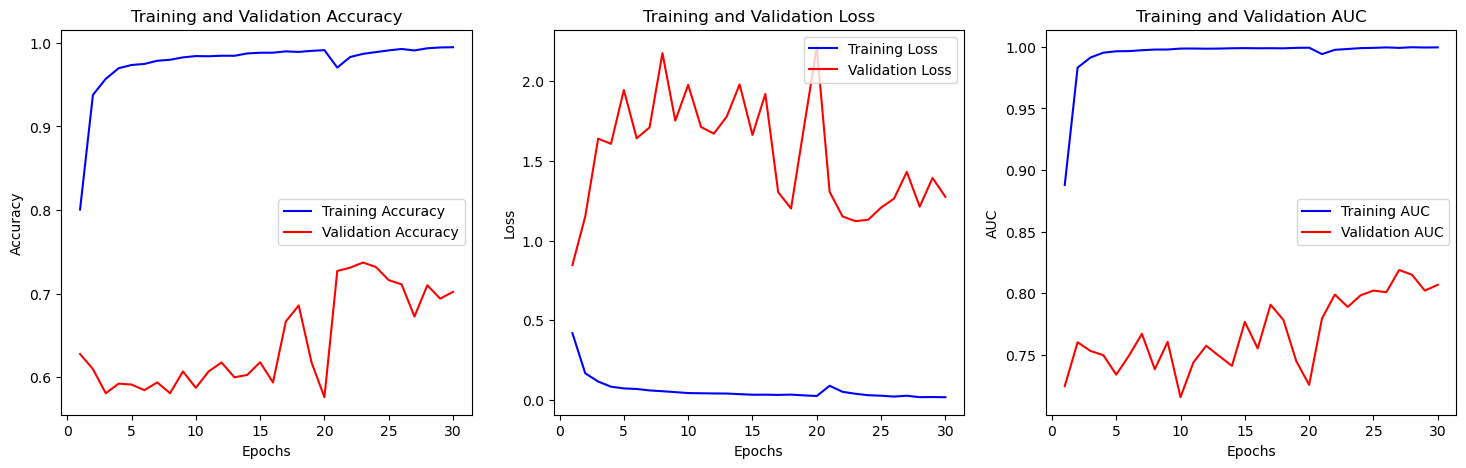

In [14]:
def Plot_Training_History(History1,History2):
    Acc=History1.history['accuracy']+History2.history['accuracy']
    Val_Acc=History1.history['val_accuracy']+History2.history['val_accuracy']
    Loss=History1.history['loss']+History2.history['loss']
    Val_Loss=History1.history['val_loss']+History2.history['val_loss']
    AUC=History1.history['auc']+History2.history['auc']
    Val_AUC=History1.history['val_auc']+History2.history['val_auc']

    Epochs=range(1,len(Acc)+1)

    plt.figure(figsize=(18,5))

    plt.subplot(1,3,1)
    plt.plot(Epochs,Acc,'b',label='Training Accuracy')
    plt.plot(Epochs,Val_Acc,'r',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(Epochs,Loss,'b',label='Training Loss')
    plt.plot(Epochs,Val_Loss,'r',label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(Epochs,AUC,'b',label='Training AUC')
    plt.plot(Epochs,Val_AUC,'r',label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()

    plt.show()

Plot_Training_History(History1,History2)